I made modelling and nex step decisions and claude helped me quickly recode the model to run efficiently to get a new baseline

* Updated with features matching CMIP6 models
* Using fixed data

In [ ]:
### Target: County-Level hourly MW

In [ ]:
##!pip install shap lightgbm pandas pyarrow --quiet

In [2]:
### Cell 2 — Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import lightgbm as lgb
import shap
from sklearn.metrics import mean_squared_error
sns.set(style="darkgrid")

In [6]:
### Cell 3 — Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
### Cell 4 — Load Data
def read_file(filename):
    directory = '/content/drive/My Drive/210_capstone/final_datasets/full_hist_attr/'
    return pd.read_parquet(directory + filename + '.parquet')

In [8]:
df = read_file('full_data_18to23_asofFeb25_1')

In [9]:
df.columns

Index(['Date', 'County', 'dpt_afternoon_k_pop', 'hdd65', 'wind_peak_ms_mean',
       'wind_low_ms_mean', 'spfh_peak_kgkg_pop', 'wind_peak_ms_pop', 'cdd75',
       'tavg_k', 'dpt_afternoon_k_mean', 'cloud_cover_pct_pop',
       'dpt_morning_k_mean', 'tmax_k_pop', 'cdd65_pop', 'cloud_cover_pct_mean',
       'tmin_k', 'hdd65_pop', 'dpt_morning_k_pop', 'wind_low_ms_pop',
       'trange_k', 'cdd65', 'tmin_k_pop', 'cdd75_pop', 'spfh_peak_kgkg_mean',
       'tmax_k', 'real_data_urma', 'staying_total', 'entering_total',
       'leaving_total', 'real_data_commuting', 'cuml_count', 'cuml_sq_foot',
       'cuml_utility_cap', 'cuml_dc_load', 'real_data_data_centers',
       'Total_Daily_Electricity_Usage', 'hour_of_max',
       'Max_Daily_Electricity_Usage', 'Public Level 1',
       'Shared Private Level 1', 'Public Level 2', 'Shared Private Level 2',
       'Public DC Fast', 'Shared Private DC Fast', 'Total',
       'real_data_ev_charging', 'BEV', 'PHEV', 'FCEV',
       'real_data_ev_poplution', 

In [11]:
### Cell 5 — Rename Columns
df = df.rename(columns={
    'Date':  'date',
    'County': 'county',
    'BEV':   'bev',
    'PHEV':  'phev',
    'FCEV':  'fcev',
    'Max_Daily_Electricity_Usage': 'electricity_usage',
    'Per_Capita_Personal_Income_Adjusted': 'est_median_income',
    'Total': 'total'
})

In [12]:
### Cell 6 — Target Engineering (BEFORE split)
df['date'] = pd.to_datetime(df['date'])
df['elec_per_capita']     = df['electricity_usage'] / df['total_pop']
df['elec_per_capita_log'] = np.log(df['elec_per_capita'])

target = 'elec_per_capita_log'

print(df.shape)
print(df['elec_per_capita'].describe())


(127078, 74)
count    127078.000000
mean          0.001019
std           0.000212
min           0.000476
25%           0.000860
50%           0.000988
75%           0.001142
max           0.002152
Name: elec_per_capita, dtype: float64


In [ ]:
# df["total_ev_pop"] = (df["total"])/df["total_pop"]

In [13]:
ROLLING_SPECS = [
    ("cdd65_pop_roll5",       "cdd65_pop",  5,  "sum"),
    ("hdd65_pop_roll5",       "hdd65_pop",  5,  "sum"),
    ("tmax_k_pop_roll5_max",  "tmax_k_pop", 5,  "max"),
    ("tmax_k_pop_roll7_mean", "tmax_k_pop", 7,  "mean"),
]

def add_rolling_features(df):
    df = df.sort_values(["county", "date"]).copy()
    g = df.groupby("county", sort=False)
    for new_col, src_col, window, agg in ROLLING_SPECS:
        df[new_col] = g[src_col].transform(
            lambda x, w=window, a=agg: getattr(x.rolling(w, min_periods=1), a)()
        )
    return df

In [14]:
# Compute 2019 mobility baseline before dropping the columns
mobility_baseline = (
    df[df['date'].dt.year == 2019]
    .groupby(['county', 'day_of_week'])[['staying_total', 'entering_total', 'leaving_total']]
    .median()
    .reset_index()
)
print("Mobility baseline shape:", mobility_baseline.shape)


Mobility baseline shape: (406, 5)


In [15]:
df = add_rolling_features(df)

# Replace mobility with frozen 2019 baseline
df = df.drop(columns=['staying_total', 'entering_total', 'leaving_total'])
df = df.merge(mobility_baseline, on=['county', 'day_of_week'], how='left')


In [32]:
df.columns.to_list()

['date',
 'county',
 'dpt_afternoon_k_pop',
 'hdd65',
 'wind_peak_ms_mean',
 'wind_low_ms_mean',
 'spfh_peak_kgkg_pop',
 'wind_peak_ms_pop',
 'cdd75',
 'tavg_k',
 'dpt_afternoon_k_mean',
 'cloud_cover_pct_pop',
 'dpt_morning_k_mean',
 'tmax_k_pop',
 'cdd65_pop',
 'cloud_cover_pct_mean',
 'tmin_k',
 'hdd65_pop',
 'dpt_morning_k_pop',
 'wind_low_ms_pop',
 'trange_k',
 'cdd65',
 'tmin_k_pop',
 'cdd75_pop',
 'spfh_peak_kgkg_mean',
 'tmax_k',
 'real_data_urma',
 'real_data_commuting',
 'cuml_count',
 'cuml_sq_foot',
 'cuml_utility_cap',
 'cuml_dc_load',
 'real_data_data_centers',
 'Total_Daily_Electricity_Usage',
 'hour_of_max',
 'electricity_usage',
 'Public Level 1',
 'Shared Private Level 1',
 'Public Level 2',
 'Shared Private Level 2',
 'Public DC Fast',
 'Shared Private DC Fast',
 'total',
 'real_data_ev_charging',
 'bev',
 'phev',
 'fcev',
 'real_data_ev_poplution',
 'est_median_income',
 'real_data_income',
 'total_pop',
 'household_pop',
 'group_quarters_pop',
 'total_households',


In [16]:
# Split
train_df = df[df['date'].dt.year <= 2021].copy()
val_df   = df[df['date'].dt.year == 2022].copy()
test_df  = df[df['date'].dt.year == 2023].copy()

print(f"Train: {train_df.shape}  ({train_df['date'].dt.year.min()}–{train_df['date'].dt.year.max()})")
print(f"Val:   {val_df.shape}")
print(f"Test:  {test_df.shape}")


Train: (84738, 78)  (2018–2021)
Val:   (21170, 78)
Test:  (21170, 78)


In [33]:
### Cell 8 — Features
selected_features = [
    # CATEGORICAL
    "county",
    "day_of_week",
    # CALENDAR
    "quarter",
    "month",
    "is_holiday",
    # TEMPERATURE
    "tmax_k_pop",
    "tmin_k_pop",
    "trange_k",
    # DEGREE DAYS
    "hdd65_pop",
    "cdd65_pop",
    "cdd75_pop",
    # ROLLING WEATHER
    "cdd65_pop_roll5",
    "hdd65_pop_roll5",
    "tmax_k_pop_roll5_max",
    "tmax_k_pop_roll7_mean",
    # HUMIDITY
    "spfh_peak_kgkg_pop",
    # WIND
    "wind_peak_ms_pop",
    # MOBILITY
    # "staying_total",
    # "entering_total",
    # "leaving_total",
    # DATA CENTERS
    "cuml_count",
    "cuml_sq_foot",
    "cuml_utility_cap",
    "cuml_dc_load",
    # EVs
     "bev",
    #   "phev",
    #  "fcev",
      # "total_ev_pop",
    # SOCIOECONOMIC
    "est_median_income",
    "total_pop",
]

cat_cols = ["county", "day_of_week"]
print(f"Features: {len(selected_features)}")

Features: 24


In [ ]:
# selected_features=["month", "total_pop", "est_median_income", "cuml_utility_cap", "cdd65_pop", "hdd65_pop", "spfh_peak_kgkg_pop", "cloud_cover_pct_pop", "wind_low_ms_pop", "wind_peak_ms_pop", "total_ev_pop"]

In [34]:
cat_cols = ["county", "day_of_week"]
print(f"Features: {len(selected_features)}")

Features: 24


In [35]:
### Cell 9 — Train Model
def set_and_align_categories(train_df, val_df, cat_cols=cat_cols):
    for c in cat_cols:
        train_df[c] = train_df[c].astype("category")
        val_df[c]   = val_df[c].astype("category")
        val_df[c]   = val_df[c].cat.set_categories(train_df[c].cat.categories)
    return train_df, val_df

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def run_model(train_df, val_df, features, params):
    X_train, y_train = train_df[features], train_df[target]
    X_val,   y_val   = val_df[features],   val_df[target]

    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train),
            (X_val,   y_val),],
        eval_names=["train","val"],
        eval_metric="rmse",
        callbacks=[lgb.early_stopping(50, verbose=False),
                   lgb.log_evaluation(period=300)]
    )

    preds_val = model.predict(X_val, num_iteration=model.best_iteration_)
    rmse_val  = rmse(y_val, preds_val)
    return model, rmse_val, preds_val, model.best_iteration_

params = dict(
    n_estimators=5000,
    learning_rate=0.02,
    num_leaves=64,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,      # L1 — add this
    reg_lambda=1.0,     # L2 — add this
    random_state=42,
)

train_df, val_df = set_and_align_categories(train_df, val_df)

model, rmse_val, preds_val, best_iter = run_model(train_df, val_df, selected_features, params)

print(f"""
rmse_val (log per capita): {rmse_val:.6f}
best_iter:                 {best_iter}
""")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008115 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4932
[LightGBM] [Info] Number of data points in the train set: 84738, number of used features: 24
[LightGBM] [Info] Start training from score -6.941684
[300]	train's rmse: 0.075661	train's l2: 0.00572459	val's rmse: 0.128426	val's l2: 0.0164932
[600]	train's rmse: 0.0704088	train's l2: 0.0049574	val's rmse: 0.124139	val's l2: 0.0154105
[900]	train's rmse: 0.0672775	train's l2: 0.00452626	val's rmse: 0.123016	val's l2: 0.0151331
[1200]	train's rmse: 0.0648155	train's l2: 0.00420105	val's rmse: 0.12241	val's l2: 0.0149842
[1500]	train's rmse: 0.0627239	train's l2: 0.00393429	val's rmse: 0.122032	val's l2: 0.0148917
[1800]	train's rmse: 0.0608564	train's l2: 0.0037035	val's rmse: 0.121853	val's l2: 0.0148481
[2100]	train's rmse: 0.0591791

In [37]:
### Cell 10 — MWh Metrics
val_df = val_df.copy()
val_df['preds_mwh'] = np.exp(preds_val) * val_df['total_pop']

def rmse_mwh(df):
    return np.sqrt(mean_squared_error(df['electricity_usage'], df['preds_mwh']))

def pct_of_mean(df):
    return 100 * rmse_mwh(df) / df['electricity_usage'].mean()

def pop_weighted_rmse_pct(df):
    w = df['total_pop'].values
    wrmse = np.sqrt(np.sum(w * (df['electricity_usage'] - df['preds_mwh'])**2) / np.sum(w))
    wmean = np.average(df['electricity_usage'], weights=w)
    return 100 * wrmse / wmean

print(f"RMSE MWh:          {rmse_mwh(val_df):,.0f}")
print(f"RMSE % of mean:    {pct_of_mean(val_df):.1f}%")
print(f"Pop-wtd RMSE %:    {pop_weighted_rmse_pct(val_df):.1f}%")


RMSE MWh:          144
RMSE % of mean:    20.5%
Pop-wtd RMSE %:    12.4%


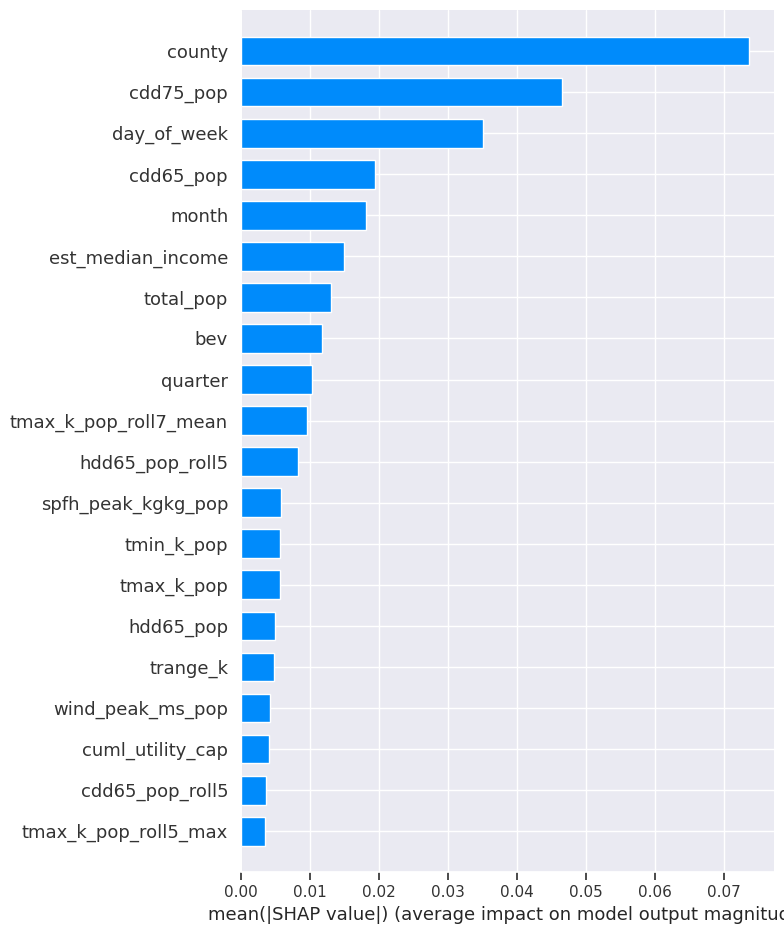

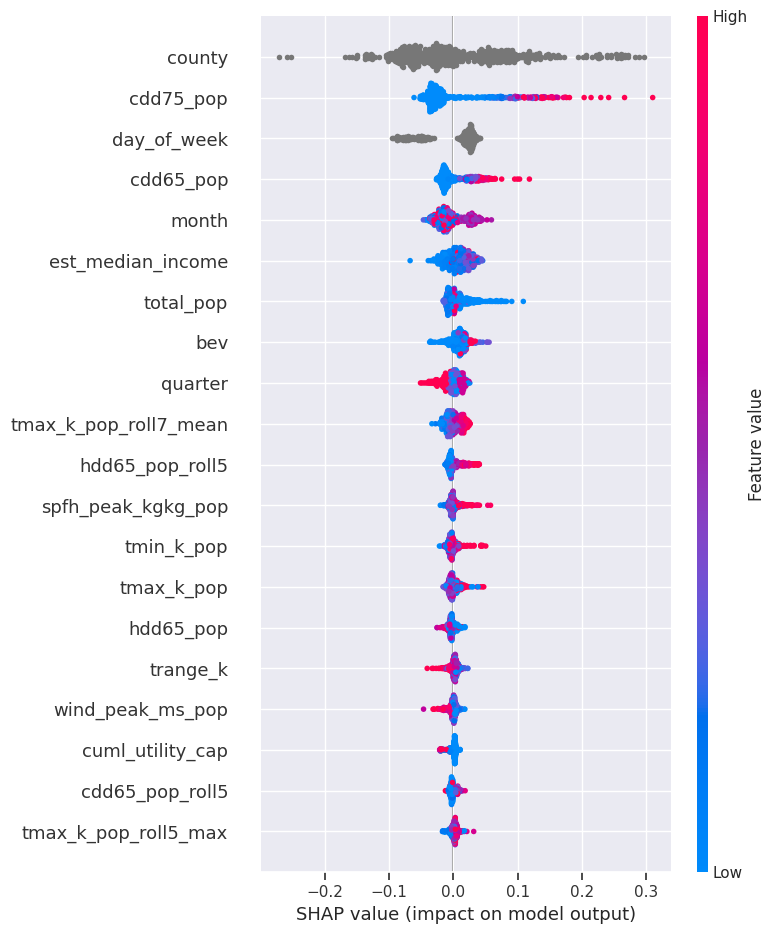

In [24]:
### Cell 11 — SHAP
explainer   = shap.TreeExplainer(model)
shap_sample = val_df[selected_features].sample(500, random_state=42)
shap_values = explainer.shap_values(shap_sample)

shap.summary_plot(shap_values, shap_sample, plot_type="bar")
shap.summary_plot(shap_values, shap_sample)


In [ ]:
#!pip install mlflow

In [25]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 47.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 811.1/811.1 kB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 17.0 MB/s eta 0:00:00


In [38]:
import mlflow
import mlflow.lightgbm
import joblib, os, tempfile
from datetime import datetime

run_ts        = datetime.now().strftime('%Y%m%d_%H%M')
model_version = 'v3'
model_name    = f'lgbm_{target}_{model_version}_{run_ts}'

MODEL_DIR = '/content/drive/My Drive/210_capstone/models'
PRED_DIR  = '/content/drive/My Drive/210_capstone/predictions'
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PRED_DIR,  exist_ok=True)

mlflow.set_tracking_uri(f'sqlite:///{MODEL_DIR}/mlflow.db')
mlflow.set_experiment('climate-feat-lgbm-peak')

with mlflow.start_run(run_name=f'lgbm_v3_{target}'):

    # ── Params ────────────────────────────────────────────────────────────
    mlflow.log_params(params)
    mlflow.log_param('target',       target)
    mlflow.log_param('n_features',   len(selected_features))
    mlflow.log_param('best_iter',    best_iter)
    mlflow.log_param('run_ts',       run_ts)

    # ── Log-space RMSE ────────────────────────────────────────────────────
    mlflow.log_metric('rmse_log_val', rmse_val)

    # ── MWh metrics ───────────────────────────────────────────────────────
    mlflow.log_metric('rmse_mwh_val',        rmse_mwh(val_df))
    mlflow.log_metric('rmse_pct_mean_val',   pct_of_mean(val_df))
    mlflow.log_metric('pop_wtd_rmse_pct_val',pop_weighted_rmse_pct(val_df))

    # ── Log model ─────────────────────────────────────────────────────────
    mlflow.lightgbm.log_model(model, artifact_path='lgbm')

    # ── Feature list as artifact ──────────────────────────────────────────
    with tempfile.NamedTemporaryFile(mode='w', suffix='.txt', delete=False) as f:
        f.write('\n'.join(selected_features))
        tmp = f.name
    mlflow.log_artifact(tmp, artifact_path='metadata')
    os.unlink(tmp)

    print(f'MLflow run logged — climate-feat-lgbm / {model_name}')
    print(f'  rmse_mwh_val:         {rmse_mwh(val_df):,.0f} MWh')
    print(f'  pop_wtd_rmse_pct_val: {pop_weighted_rmse_pct(val_df):.1f}%')

# ── Export ────────────────────────────────────────────────────────────────────
joblib.dump(model,             f'{MODEL_DIR}/{model_name}.pkl')
joblib.dump(selected_features, f'{MODEL_DIR}/{model_name}_features.pkl')
mobility_baseline.to_parquet(  f'{MODEL_DIR}/mobility_baseline_2019.parquet')

val_df['elec_per_capita_log_actual'] = val_df[target]
val_df['elec_per_capita_log_pred']   = preds_val

pred_cols = ['county', 'date', 'total_pop', 'electricity_usage',
             'elec_per_capita_log_actual', 'elec_per_capita_log_pred', 'preds_mwh']
val_df[pred_cols].to_parquet(f'{PRED_DIR}/{model_name}_preds_val.parquet', index=False)

print(f'\nExported:')
print(f'  {model_name}.pkl')
print(f'  {model_name}_features.pkl')
print(f'  mobility_baseline_2019.parquet')
print(f'  {model_name}_preds_val.parquet')

2026/02/27 05:52:34 INFO mlflow.tracking.fluent: Experiment with name 'climate-feat-lgbm-peak' does not exist. Creating a new experiment.
2026/02/27 05:52:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/27 05:52:35 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MLflow run logged — climate-feat-lgbm / lgbm_elec_per_capita_log_v3_20260227_0552
  rmse_mwh_val:         144 MWh
  pop_wtd_rmse_pct_val: 12.4%

Exported:
  lgbm_elec_per_capita_log_v3_20260227_0552.pkl
  lgbm_elec_per_capita_log_v3_20260227_0552_features.pkl
  mobility_baseline_2019.parquet
  lgbm_elec_per_capita_log_v3_20260227_0552_preds_val.parquet
